# Drug Response Prediction with Measured Profiles

Measured profiles originate from sciplex and Mcfarland dataset.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr,ttest_ind, spearmanr
from sklearn.metrics import mean_squared_error
import numpy as np

In [2]:
# Get the project root directory
from pathlib import Path
import sys

project_root = Path.cwd()
sys.path.append(str(project_root.parent))

from notebook_imports import *

In [3]:
# Set project directories using configuration
home_dir = str(config.PROJECT_ROOT)
data_dir = str(config.DATA_DIR)
resources_dir = str(config.RESOURCES_DIR)
results_dir = str(config.RESULTS_04_DIR)
figures_dir = str(config.FIGURES_04_DIR)

In [4]:
# Prediction evaluation function. Either pearsonr or spearmanr
evaluation_function = pearsonr

# Drug to perturbation mapping
mcfarland_drug_to_pert = pd.read_csv(os.path.join(resources_dir, 'mcfarland_drug_to_perturbation.csv'))

In [5]:
# Color palettes
pre_post_lfc_palette = {
    'Grey': '#808080',       # Standard grey
    'Red': '#FF0000',        # Bright red
    'Dark Red': '#8B0000'    # Dark red
}
pre_post_lfc_palette = list(pre_post_lfc_palette.values())
    
sens_res_palette = {
    'Resistant': 'darkgrey',  # plum
    'Sensitive': '#FF0000'   # olive
}

In [6]:
def preprocess_for_plotting(results, predictions):
    results['feature_selection'] = results['feature_selection'].replace({'top100 highest variance': 'top100 HVG', 
                                                                                       'top1000 highest variance': 'top1000 HVG',
                                                                                       'top3000 highest variance': 'top3000 HVG',
                                                                                       'DE genes': 'tissue label'})
    
    results = results.replace({'LFC': 'LFC', 'pre_treatment': 'Pre', 'post_treatment': 'Post'})

    results['model'] = np.where(results['feature_selection']=='tissue label', 'tissue label', results['model'])
    results.drop_duplicates(inplace=True)

    predictions['feature_selection'] = predictions['feature_selection'].replace({'top100 highest variance': 'top100 HVG', 
                                        'top1000 highest variance': 'top1000 HVG',
                                        'top3000 highest variance': 'top3000 HVG',
                                        'DE genes': 'tissue label'})
    
    predictions = predictions.replace({'pre-treatment': 'pre_treatment', 'post-treatment': 'post_treatment'})
    predictions = predictions.replace({'LFC': 'LFC', 'pre_treatment': 'Pre', 'post_treatment': 'Post'})
    predictions['model'] = pd.Categorical(predictions['model'], categories=['Pre','Post', 'LFC'], ordered=True)

    predictions['pred_label'] = np.where(predictions['pred'] > 0.2, 1, 0)
    predictions['true_label'] = np.where(predictions['true'] > 0.2, 1, 0)

    return results, predictions

The model is tested in 4 scenarios:
- Unseen (cell line, drug) combination
- Unseen drug
- Unseen cell line
- Unseen drug & unseen cell line

In [7]:
mcfarland_result = pd.read_csv(os.path.join(results_dir,  'mcfarland_regression_seen_seen_cv5.csv'), index_col=0)
mcfarland_predictions = pd.read_csv(os.path.join(results_dir,'mcfarland_regression_predictions_seen_seen_cv5.csv'), index_col=0)
mcfarland_result, mcfarland_predictions = preprocess_for_plotting(mcfarland_result, mcfarland_predictions)

In [8]:
mcfarland_predictions['test_condition'] = mcfarland_predictions['test_condition'].str.replace('condition=', '')
mcfarland_predictions['test_condition'] = mcfarland_predictions['test_condition'].str.replace('AND tissue=', '')
mcfarland_predictions['test_condition'] = mcfarland_predictions['test_condition'].str.replace(' ', '_')

In [9]:
unique_test_conditions = mcfarland_predictions['test_condition'].unique()

In [10]:
groupby = ['model', 'feature_selection', 'tissue']

counts = mcfarland_predictions.groupby(groupby).size().reset_index(name='count')

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\734925046.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = mcfarland_predictions.groupby(groupby).size().reset_index(name='count')


In [11]:
ldo_scores = pd.read_csv(os.path.join(results_dir,  'mcfarland_regression_LDO_cv5.csv'), index_col=0)
ldo_predictions = pd.read_csv(os.path.join(results_dir,'mcfarland_regression_LDO_cv5_predictions.csv'), index_col=0)

ldo_scores, ldo_predictions = preprocess_for_plotting(ldo_scores, ldo_predictions)
ldo_predictions['test_condition'] = ldo_predictions['test_condition'].str.removeprefix('condition=')

ldo_predictions['test_condition'] = ldo_predictions['condition'].astype(str) + '_' + ldo_predictions['tissue'].astype(str)
ldo_predictions = ldo_predictions[ldo_predictions['test_condition'].isin(unique_test_conditions)]


In [12]:
lto_scores = pd.read_csv(os.path.join(results_dir,  'mcfarland_regression_LTO_cv5.csv'), index_col=0)
lto_predictions = pd.read_csv(os.path.join(results_dir,'mcfarland_regression_LTO_cv5_predictions.csv'), index_col=0)
lto_predictions['test_condition'] = lto_predictions['test_condition'].str.removeprefix('tissue=')

lto_scores, lto_predictions = preprocess_for_plotting(lto_scores, lto_predictions)

lto_predictions['test_condition'] = lto_predictions['condition'].astype(str) + '_' + lto_predictions['tissue'].astype(str)
lto_predictions = lto_predictions[lto_predictions['test_condition'].isin(unique_test_conditions)]
print(lto_predictions.shape)


(2703, 11)


In [13]:
loo_scores = pd.read_csv(os.path.join(results_dir,  'mcfarland_regression_LOO_cv5.csv'), index_col=0).replace({'pre-treatment': 'Pre', 'post-treatment': 'Post'})
loo_predictions = pd.read_csv(os.path.join(results_dir,'mcfarland_regression_LOO_cv5_predictions.csv'), index_col=0).replace({'pre-treatment': 'Pre', 'post-treatment': 'Post'})

loo_scores['test_condition'] = loo_scores['test_condition'].str.replace('tissue=','')
loo_scores['test_condition'] = loo_scores['test_condition'].str.replace('OR condition=','')
loo_scores[['tissue_test', 'condition_test']] = loo_scores['test_condition'].str.split(' ', expand=True)

loo_predictions['test_condition'] = loo_predictions['test_condition'].str.replace('tissue=','')
loo_predictions['test_condition'] = loo_predictions['test_condition'].str.replace('OR condition=','')
loo_predictions[['tissue_test', 'condition_test']] = loo_predictions['test_condition'].str.split(' ', expand=True)

loo_predictions = loo_predictions[(loo_predictions['tissue']==loo_predictions['tissue_test'])& (loo_predictions['condition']==loo_predictions['condition_test'])]


loo_predictions['test_condition'] = loo_predictions['condition'].astype(str) + '_' + loo_predictions['tissue'].astype(str)
loo_predictions = loo_predictions[loo_predictions['test_condition'].isin(unique_test_conditions)]

In [14]:
groupby = ['model', 'feature_selection', 'split']

pearson_result = mcfarland_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

ldo_pearson_result = ldo_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')


lto_pearson_result = lto_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

loo_pearson_result = loo_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy').fillna(0)

# skip_tissue_types = list(set(ldo_predictions['tissue'].unique()).difference(set(lto_predictions['tissue'].unique())))

# lto_pearson_result = lto_pearson_result[lto_pearson_result['tissue'].isin(skip_tissue_types)==False].copy()
# ldo_pearson_result = ldo_pearson_result[ldo_pearson_result['tissue'].isin(skip_tissue_types)==False].copy()
# pearson_result = pearson_result[pearson_result['tissue'].isin(skip_tissue_types)==False].copy()
# loo_pearson_result = loo_pearson_result[loo_pearson_result['tissue'].isin(skip_tissue_types)==False].copy()

all_results = pd.concat([pearson_result.assign(test='T1:\nSeen drug, \nseen cell line'), ldo_pearson_result.assign(test='T3:\nUnseen drug,\nseen cell line'), lto_pearson_result.assign(test='T2:\nSeen drug,\nunseen cell line'), loo_pearson_result.assign(test='T4:\nUnseen drug,\nunseen cell line')])

all_results = all_results.rename(columns={'tissue': 'test_instance'})
all_results['accuracy'] = all_results['accuracy'].fillna(0)

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\634155124.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pearson_result = mcfarland_predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\634155124.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pearson_result = mcfarland_predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\634155124.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in 

In [15]:
groupby = ['model', 'feature_selection', 'condition']

pearson_result = mcfarland_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

ldo_pearson_result = ldo_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')


lto_pearson_result = lto_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

loo_pearson_result = loo_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy').fillna(0)


all_results_condition = pd.concat([pearson_result.assign(test='T1:\nSeen drug, \nseen cell line'), ldo_pearson_result.assign(test='T3:\nUnseen drug,\nseen cell line'), lto_pearson_result.assign(test='T2:\nSeen drug,\nunseen cell line'), loo_pearson_result.assign(test='T4:\nUnseen drug,\nunseen cell line')])

all_results_condition = all_results_condition.rename(columns={'tissue': 'test_instance'})
all_results_condition['accuracy'] = all_results_condition['accuracy'].fillna(0)

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\3208153904.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pearson_result = mcfarland_predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\3208153904.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pearson_result = mcfarland_predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\3208153904.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True 

In [36]:
from itertools import combinations
from collections import defaultdict
from statsmodels.stats.multitest import multipletests

def plot_outcomes2(
    all_results,
    title="",
    yscale='linear',
    ylim=None,
    figsize=(9, 5.5),
):
    fig, ax = plt.subplots(figsize=figsize, dpi=300, layout='constrained')

    # Define categorical order
    model_order = sorted(all_results['model'].unique(), reverse=True)  # Ensure models are always in the same order
    feature_order = [
        'T1:\nSeen drug, \nseen cell line',
        'T2:\nSeen drug,\nunseen cell line',
        'T3:\nUnseen drug,\nseen cell line',
        'T4:\nUnseen drug,\nunseen cell line'
    ]  # Consistent order for feature selection

    # Convert to categorical with explicit order
    all_results['model'] = pd.Categorical(all_results['model'], categories=model_order, ordered=True)
    all_results['test'] = pd.Categorical(all_results['test'], categories=feature_order, ordered=True)

    # Sort dataframe to match the categorical order
    all_scores = all_results.sort_values(['model', 'test'])

    palette = [pre_post_lfc_palette[0], pre_post_lfc_palette[1], pre_post_lfc_palette[2]]

    # -- Boxplot
    sns.boxplot(
        data=all_scores,
        x='test',
        y='accuracy',
        hue='model',
        palette=palette,
        width=0.65,
        ax=ax,
    )

    # --- Custom swarm centering ---
    # Seaborn's dodge behavior for swarmplot often does not align with boxplot categories.
    # To center points, we manually calculate their positions.
    import numpy as np

    grouped = all_scores.groupby(["test", "model"], observed=True)
    x_locs = {cat: i for i, cat in enumerate(feature_order)}
    n_models = len(model_order)
    bar_width = 0.6   # Match box width as much as possible

    # Offset for center-aligned swarms for each model
    offset_lookup = {
        model: (idx - (n_models - 1)/2) * (bar_width / n_models)
        for idx, model in enumerate(model_order)
    }

    for i, test in enumerate(feature_order):
        for j, model in enumerate(model_order):
            group = all_scores[(all_scores['test'] == test) & (all_scores['model'] == model)]
            if group.shape[0] == 0:
                continue
            # Calculate centered x position for each point in this model
            x_center = x_locs[test] + offset_lookup[model]
            # Spread (jitter) along x within this group
            # We use matplotlib scatter directly for precise control
            y = group['accuracy'].values
            # Sort y for visual aesthetics, then add a little random jitter for visibility
            if len(y) == 1:
                x_vals = [x_center]
            else:
                # Use np.linspace for even horizontal jitter, scaled to avoid overlap
                x_span = (bar_width / n_models) * 0.25  # scale down max jitter
                x_vals = np.linspace(x_center - x_span/2, x_center + x_span/2, len(y))
            ax.scatter(
                x_vals,
                y,
                s=60,  # pt size
                color=palette[j], # color matches box
                edgecolor='black',
                linewidth=0.5,
                alpha=0.6,
                zorder=4,
                label=None # Remove the points from the legend
            )

    sns.despine(ax=ax, offset=5, trim=False)

    ax.yaxis.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)
    ax.set_axisbelow(True)

    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=18)
    ax.set_ylabel(r'Pearson r $\rightarrow$', fontsize=22)

    ax.tick_params(axis='y', labelsize=18)
    ax.set_yscale(yscale)
    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        y = all_scores['accuracy'].dropna()
        y_pad = max(0.05, 0.08 * (y.max() - y.min()))
        ax.set_ylim(y.min() - y_pad, y.max() + y_pad)
    ax.margins(x=0.02)
    ax.set_xlim(-0.5, len(feature_order) - 0.5)

    # Calculate p-values
    p_values = []
    for test in all_scores['test'].unique():
        subset = all_scores[all_scores['test'] == test]
        models = subset['model'].unique()
        for model1, model2 in combinations(models, 2):
            auc1 = subset[subset['model'] == model1]['accuracy']
            auc2 = subset[subset['model'] == model2]['accuracy']
            _, p_value = ttest_ind(auc1, auc2)
            p_values.append((test, model1, model2, p_value))
    p_values_df = pd.DataFrame(p_values, columns=['test', 'model1', 'model2', 'p_value'])
    p_values_df['adjusted_p_value'] = multipletests(p_values_df['p_value'], method='fdr_bh')[1]

    # Add p-values to the plot
    bar_width = 1 / (len(model_order) + 1)
    y_offset = 0.02
    line_height = y_offset / 2
    annotation_levels = defaultdict(float)  # tracks current top for each 'test'

    # Make the title bold
    ax.set_title(title, fontsize=18, fontweight='bold')
    # fig.text(0.52, 0.87, 
    #          fr"Drug Response Prediction{BR}{subtitle}", 
    #          ha='center', va='bottom', fontsize=24, fontweight='bold')

    ax.legend(
        title='',
        fontsize=16,
        frameon=False,
        loc='upper left',
        bbox_to_anchor=(0.01, 0.25),
    )

    return fig, ax


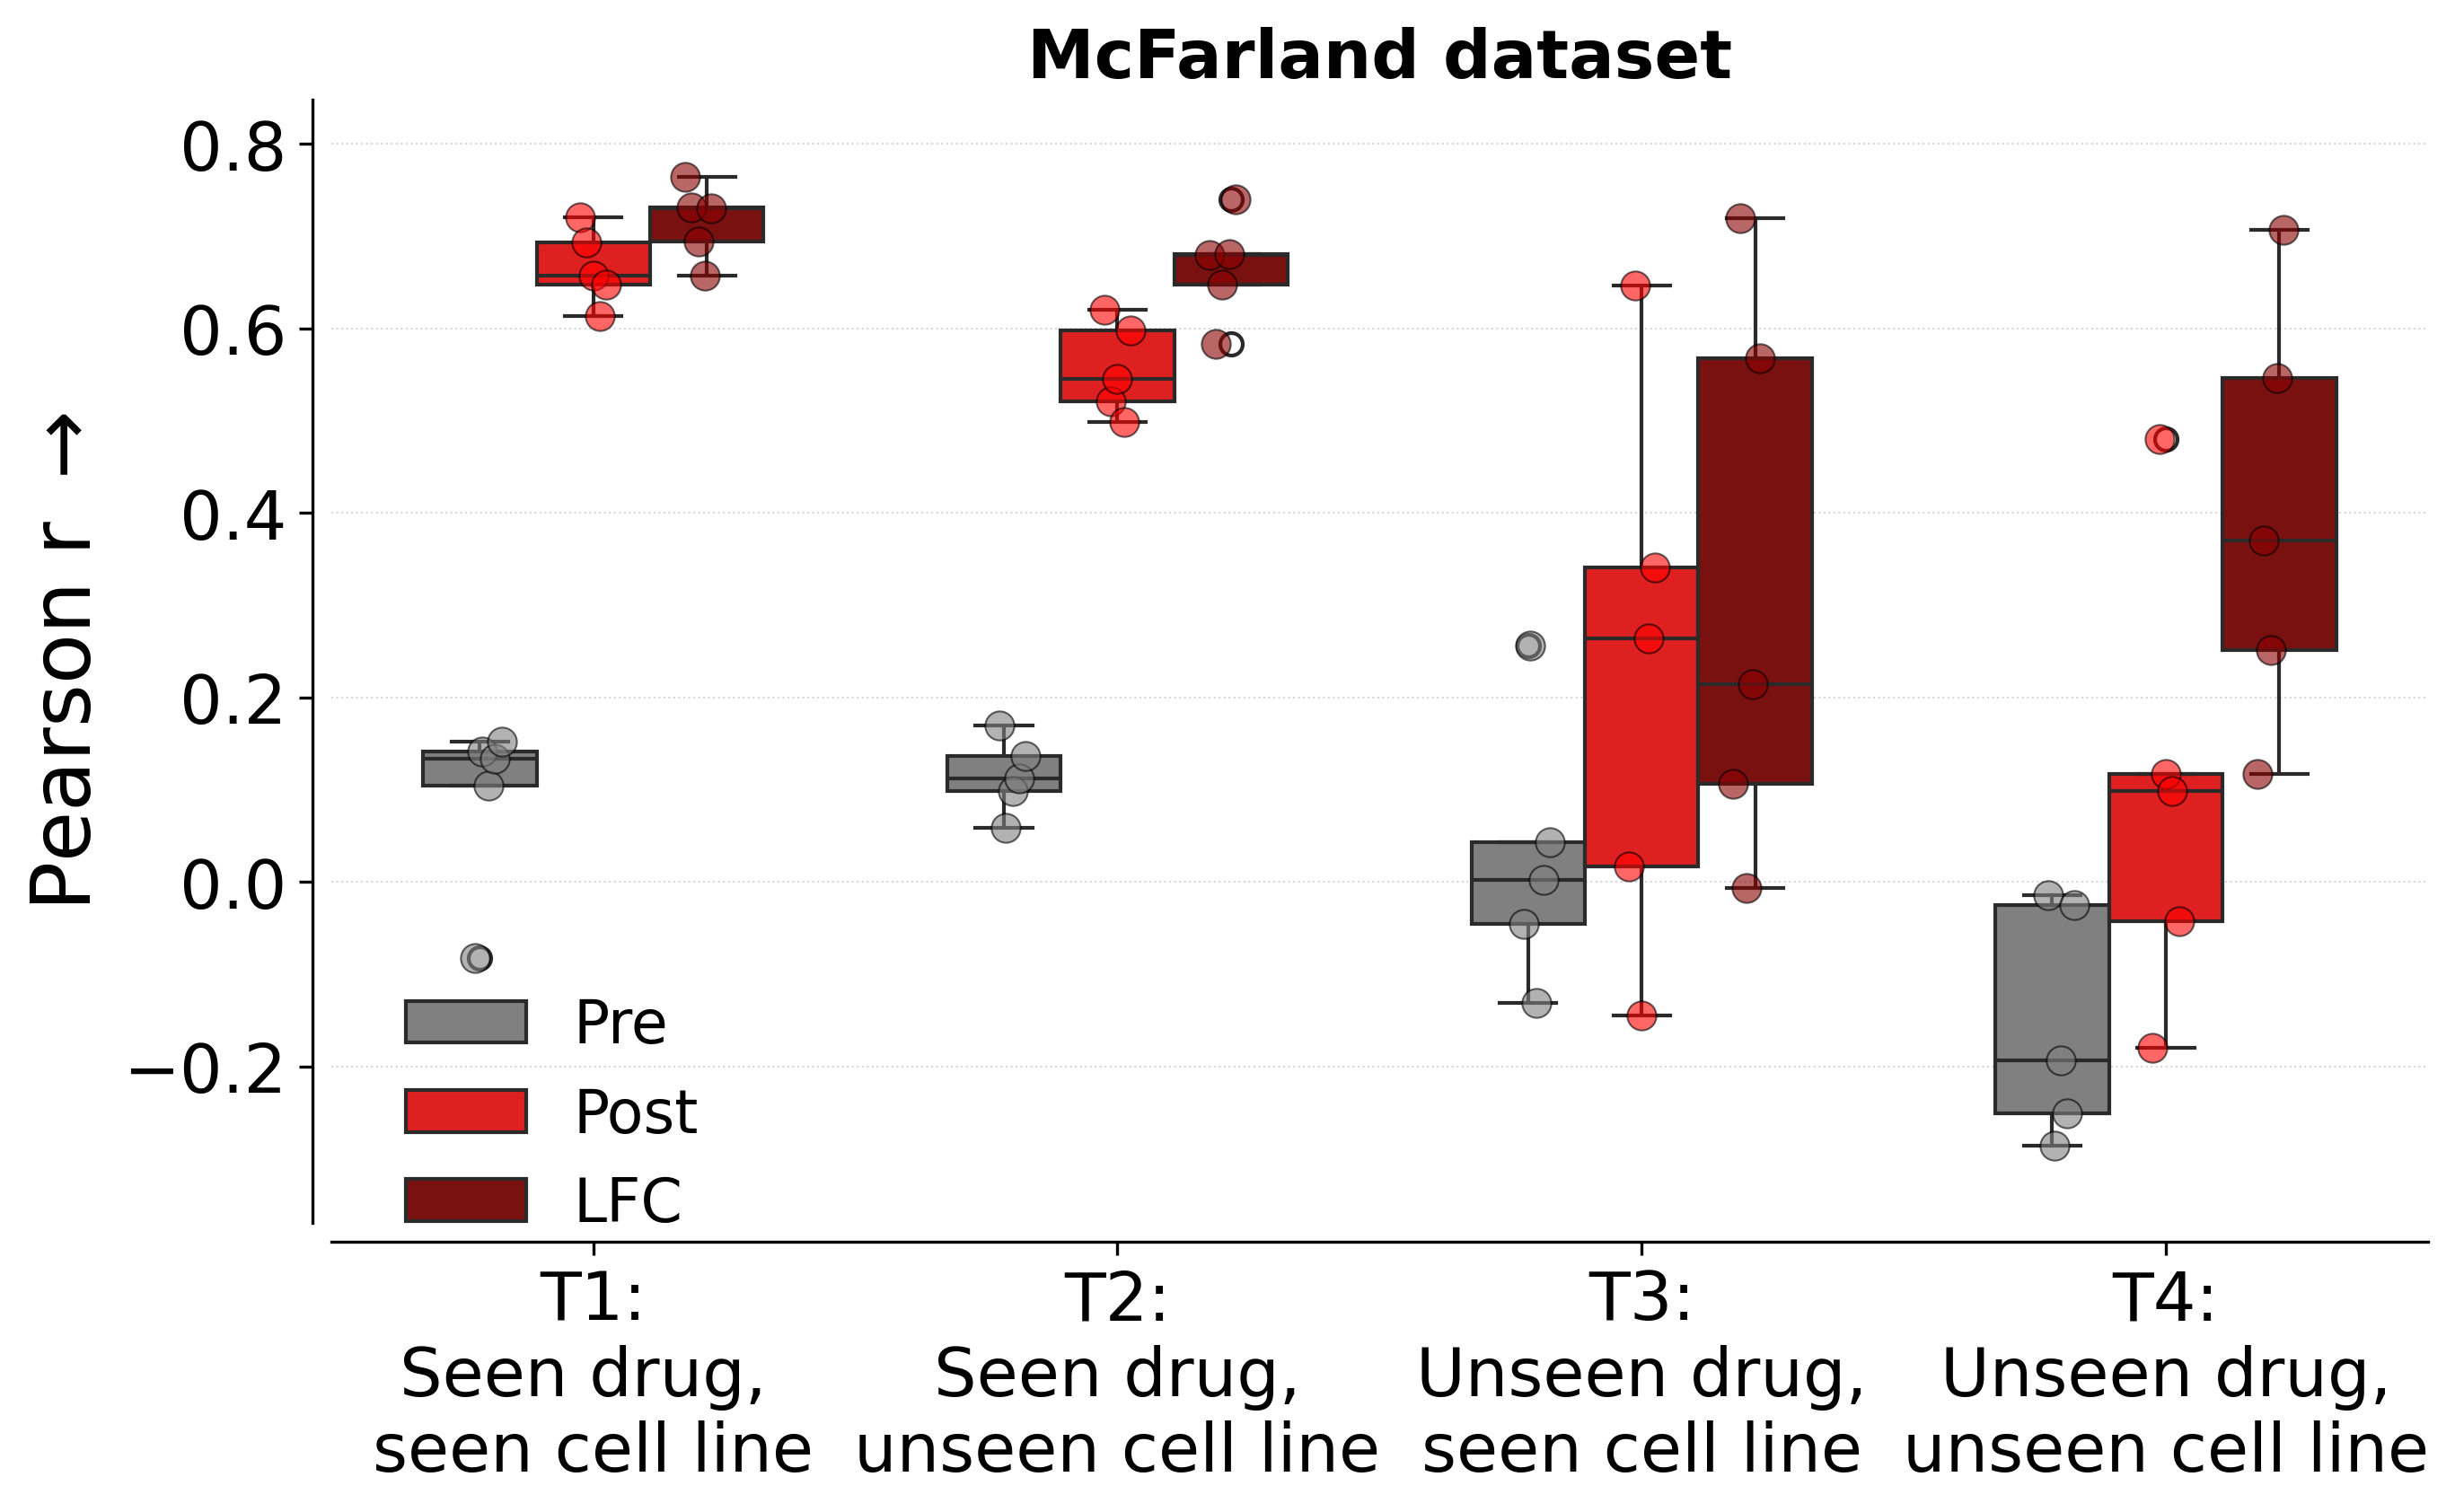

In [37]:
plot_outcomes2(all_results,title="McFarland dataset")
plt.savefig(os.path.join(figures_dir,'fullmodel_boxplot.pdf'),
 bbox_inches='tight')
plt.show()
    

### SciPlex (measured pseudobulk)

Same aggregation as McFarland: seen/seen, LDO, LTO, and LOO splits, pooled across tissues/drugs and conditions. Uses `sciplex_regression_*.csv` from `results/04_predict_drug_response/`.

In [38]:
# SciPlex: load splits and align held-out instances with seen/seen (same cleaning as McFarland block above)
splx_seen_result = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_seen_seen.csv'), index_col=0)
splx_seen_predictions = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_predictions_seen_seen.csv'), index_col=0)

splx_seen_result, splx_seen_predictions = preprocess_for_plotting(splx_seen_result, splx_seen_predictions)

splx_seen_predictions['test_condition'] = splx_seen_predictions['test_condition'].str.replace('condition=', '')
splx_seen_predictions['test_condition'] = splx_seen_predictions['test_condition'].str.replace('AND tissue=', '')
splx_seen_predictions['test_condition'] = splx_seen_predictions['test_condition'].str.replace(' ', '_')

splx_unique_test_conditions = splx_seen_predictions['test_condition'].unique()

splx_ldo_scores = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_LDO.csv'), index_col=0)
splx_ldo_predictions = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_LDO_predictions.csv'), index_col=0)
splx_ldo_scores, splx_ldo_predictions = preprocess_for_plotting(splx_ldo_scores, splx_ldo_predictions)
splx_ldo_predictions['test_condition'] = splx_ldo_predictions['test_condition'].str.removeprefix('condition=')
splx_ldo_predictions['test_condition'] = splx_ldo_predictions['condition'].astype(str) + '_' + splx_ldo_predictions['tissue'].astype(str)
splx_ldo_predictions = splx_ldo_predictions[splx_ldo_predictions['test_condition'].isin(splx_unique_test_conditions)]

splx_lto_scores = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_LTO.csv'), index_col=0)
splx_lto_predictions = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_LTO_predictions.csv'), index_col=0)
splx_lto_predictions['test_condition'] = splx_lto_predictions['test_condition'].str.removeprefix('tissue=')
splx_lto_scores, splx_lto_predictions = preprocess_for_plotting(splx_lto_scores, splx_lto_predictions)
splx_lto_predictions['test_condition'] = splx_lto_predictions['condition'].astype(str) + '_' + splx_lto_predictions['tissue'].astype(str)
splx_lto_predictions = splx_lto_predictions[splx_lto_predictions['test_condition'].isin(splx_unique_test_conditions)]

splx_loo_scores = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_LOO.csv'), index_col=0).replace({'pre-treatment': 'Pre', 'post-treatment': 'Post'})
splx_loo_predictions = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_LOO_predictions.csv'), index_col=0).replace({'pre-treatment': 'Pre', 'post-treatment': 'Post'})
splx_loo_scores['test_condition'] = splx_loo_scores['test_condition'].str.replace('tissue=', '')
splx_loo_scores['test_condition'] = splx_loo_scores['test_condition'].str.replace('OR condition=', '')
splx_loo_scores[['tissue_test', 'condition_test']] = splx_loo_scores['test_condition'].str.split(' ', expand=True)
splx_loo_predictions['test_condition'] = splx_loo_predictions['test_condition'].str.replace('tissue=', '')
splx_loo_predictions['test_condition'] = splx_loo_predictions['test_condition'].str.replace('OR condition=', '')
splx_loo_predictions[['tissue_test', 'condition_test']] = splx_loo_predictions['test_condition'].str.split(' ', expand=True)
splx_loo_predictions = splx_loo_predictions[
    (splx_loo_predictions['tissue'] == splx_loo_predictions['tissue_test'])
    & (splx_loo_predictions['condition'] == splx_loo_predictions['condition_test'])
]
splx_loo_predictions['test_condition'] = splx_loo_predictions['condition'].astype(str) + '_' + splx_loo_predictions['tissue'].astype(str)
splx_loo_predictions = splx_loo_predictions[splx_loo_predictions['test_condition'].isin(splx_unique_test_conditions)]

In [39]:
# Pearson r per tissue (here tissue == cell line for SciPlex) and per condition; pool with McFarland-style test labels
groupby_tissue = ['model', 'feature_selection', 'split']

splx_pearson_result = splx_seen_predictions.groupby(groupby_tissue).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

splx_ldo_pearson_result = splx_ldo_predictions.groupby(groupby_tissue).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

splx_lto_pearson_result = splx_lto_predictions.groupby(groupby_tissue).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

splx_loo_pearson_result = splx_loo_predictions.groupby(groupby_tissue).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy').fillna(0)

# splx_skip_tissue_types = list(set(splx_ldo_predictions['tissue'].unique()).difference(set(splx_lto_predictions['tissue'].unique())))
# splx_lto_pearson_result = splx_lto_pearson_result[splx_lto_pearson_result['tissue'].isin(splx_skip_tissue_types) == False].copy()
# splx_ldo_pearson_result = splx_ldo_pearson_result[splx_ldo_pearson_result['tissue'].isin(splx_skip_tissue_types) == False].copy()
# splx_pearson_result = splx_pearson_result[splx_pearson_result['tissue'].isin(splx_skip_tissue_types) == False].copy()
# splx_loo_pearson_result = splx_loo_pearson_result[splx_loo_pearson_result['tissue'].isin(splx_skip_tissue_types) == False].copy()

splx_all_results = pd.concat([
    splx_pearson_result.assign(test='T1:\nSeen drug, \nseen cell line'),
    splx_ldo_pearson_result.assign(test='T3:\nUnseen drug,\nseen cell line'),
    splx_lto_pearson_result.assign(test='T2:\nSeen drug,\nunseen cell line'),
    splx_loo_pearson_result.assign(test='T4:\nUnseen drug,\nunseen cell line'),
])
splx_all_results = splx_all_results.rename(columns={'tissue': 'test_instance'})
splx_all_results['accuracy'] = splx_all_results['accuracy'].fillna(0)

# groupby_condition = ['model', 'feature_selection', 'condition']
# splx_pearson_result_c = splx_seen_predictions.groupby(groupby_condition).apply(
#     lambda group: evaluation_function(group['true'], group['pred'])[0]
# ).reset_index(name='accuracy')
# splx_ldo_pearson_result_c = splx_ldo_predictions.groupby(groupby_condition).apply(
#     lambda group: evaluation_function(group['true'], group['pred'])[0]
# ).reset_index(name='accuracy')
# splx_lto_pearson_result_c = splx_lto_predictions.groupby(groupby_condition).apply(
#     lambda group: evaluation_function(group['true'], group['pred'])[0]
# ).reset_index(name='accuracy')
# splx_loo_pearson_result_c = splx_loo_predictions.groupby(groupby_condition).apply(
#     lambda group: evaluation_function(group['true'], group['pred'])[0]
# ).reset_index(name='accuracy').fillna(0)

# splx_all_results_condition = pd.concat([
#     splx_pearson_result_c.assign(test='T1:\nSeen drug, \nseen cell line'),
#     splx_ldo_pearson_result_c.assign(test='T3:\nUnseen drug,\nseen cell line'),
#     splx_lto_pearson_result_c.assign(test='T2:\nSeen drug,\nunseen cell line'),
#     splx_loo_pearson_result_c.assign(test='T4:\nUnseen drug,\nunseen cell line'),
# ])
# splx_all_results_condition = splx_all_results_condition.rename(columns={'tissue': 'test_instance'})
# splx_all_results_condition['accuracy'] = splx_all_results_condition['accuracy'].fillna(0)

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\2306738278.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  splx_pearson_result = splx_seen_predictions.groupby(groupby_tissue).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\2306738278.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda group: evaluation_function(group['true'], group['pred'])[0]
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_38268\2306738278.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to

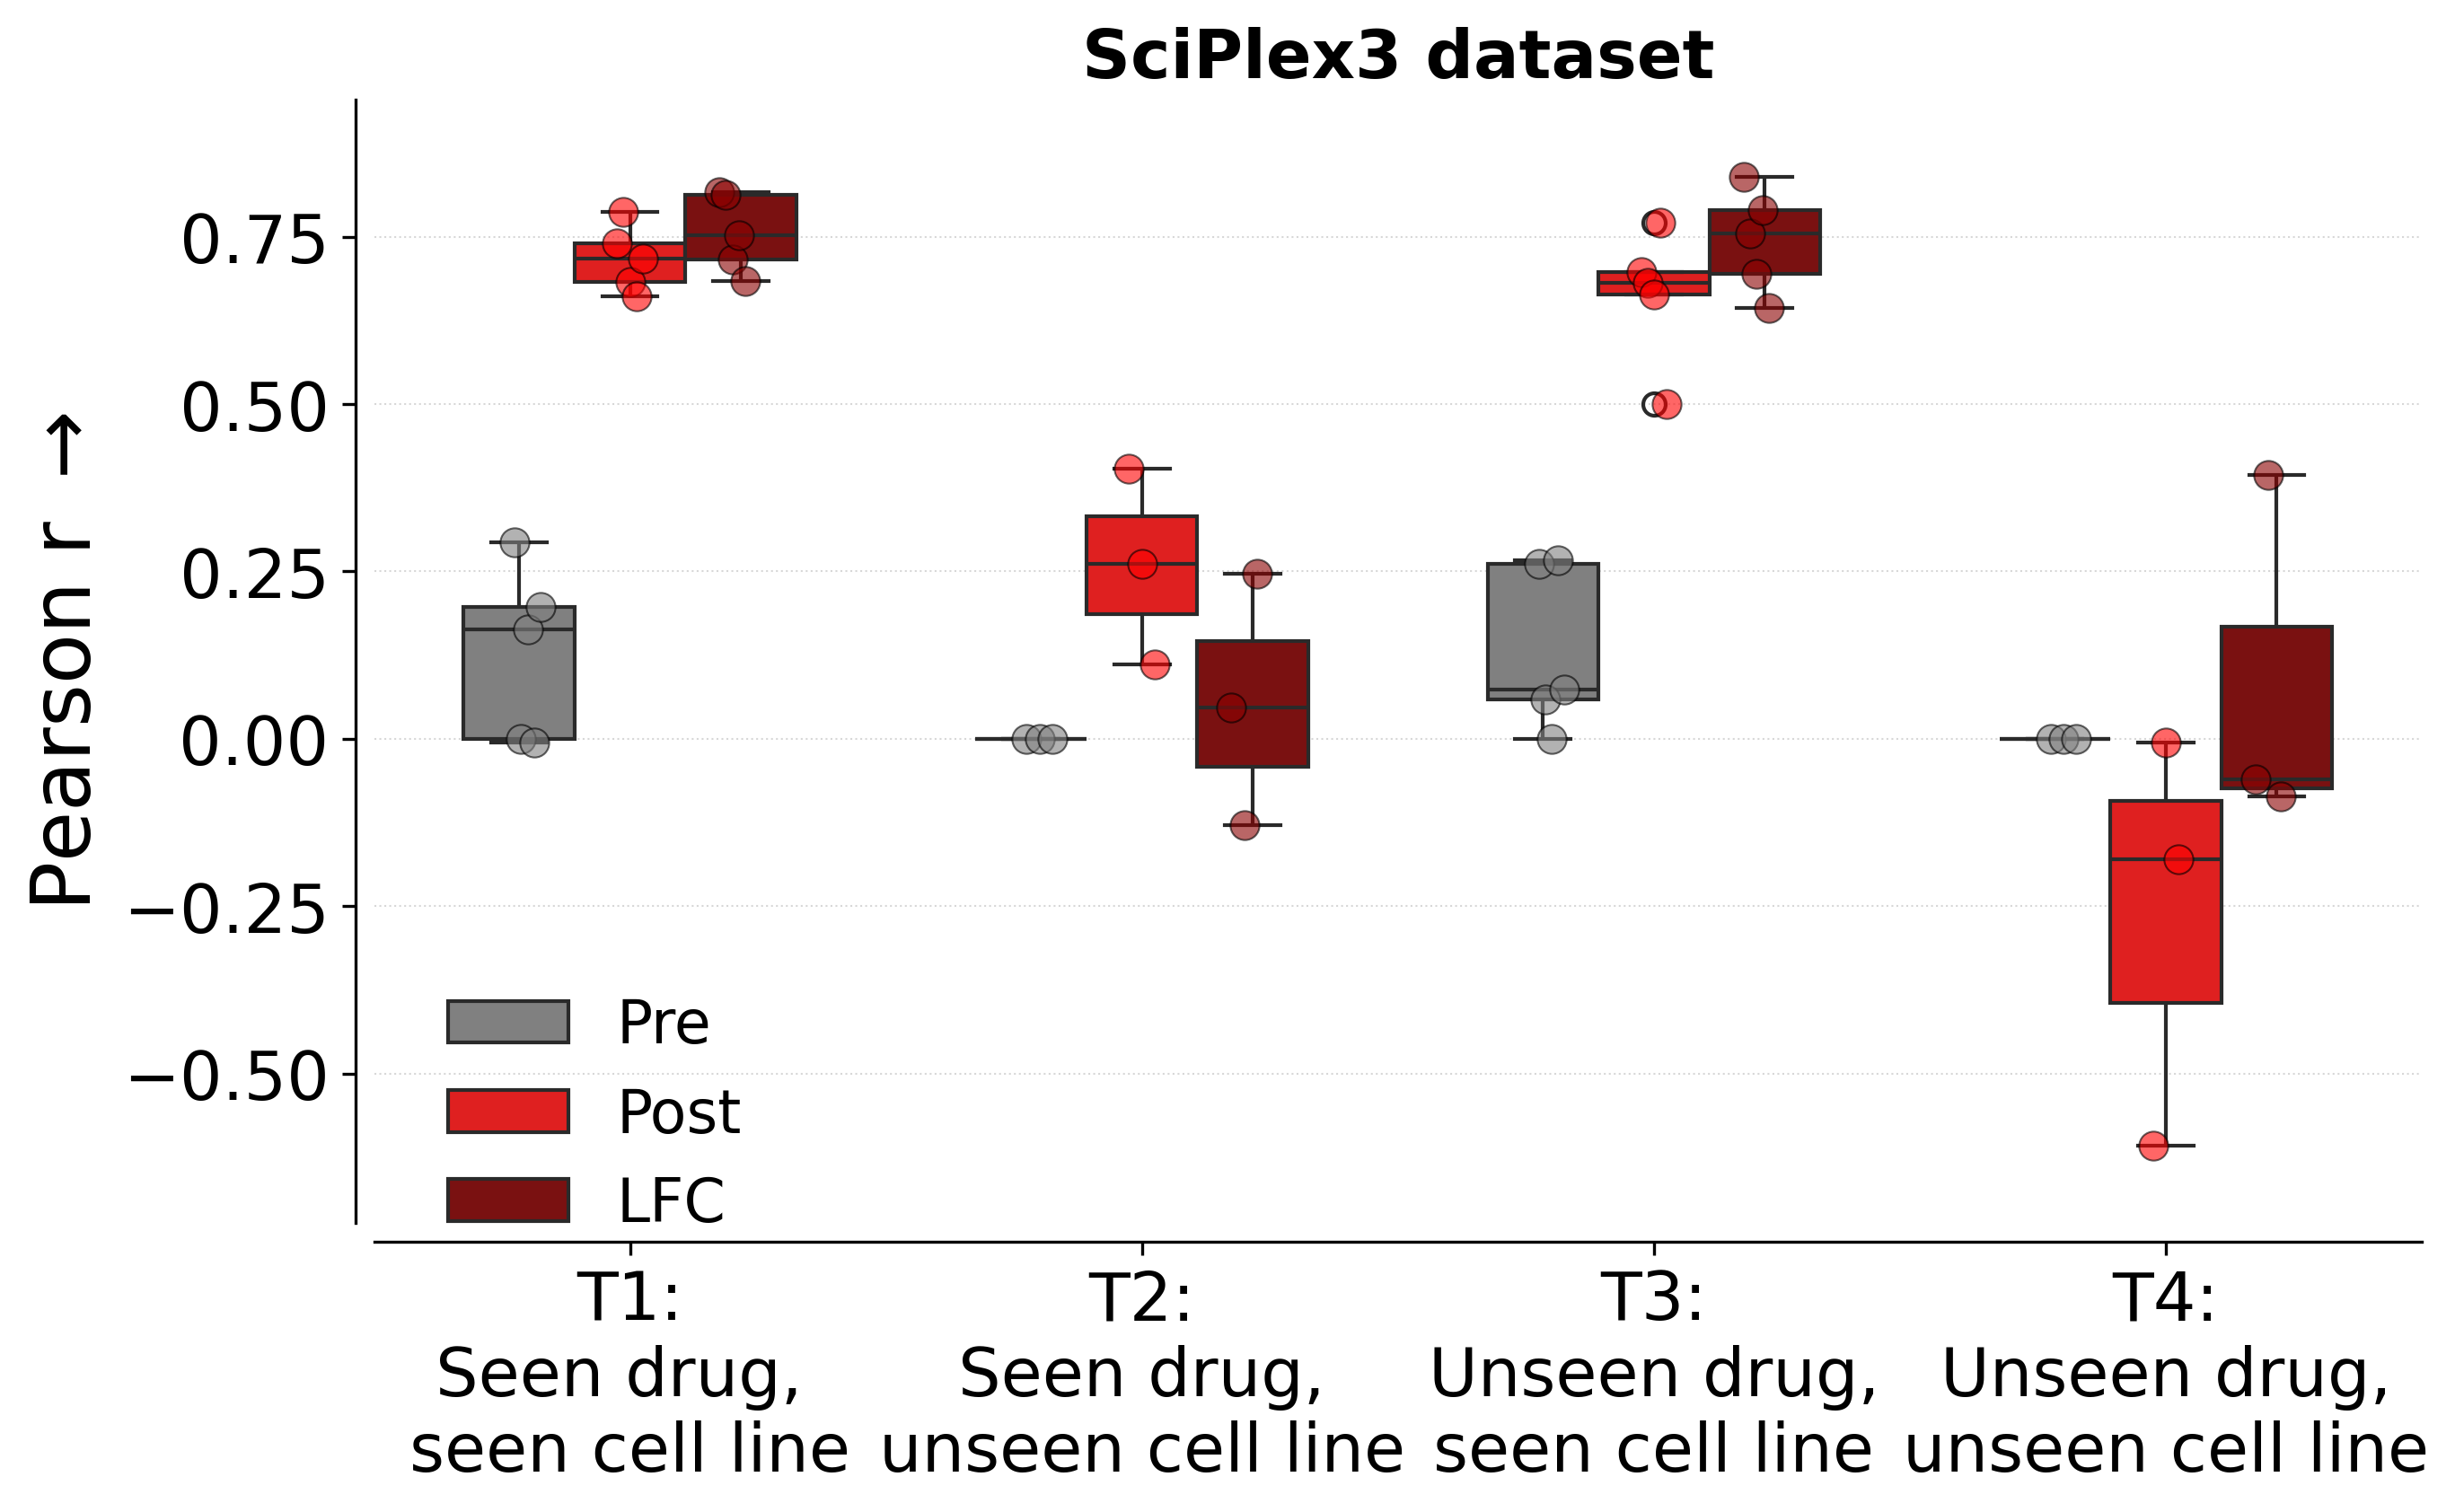

In [41]:
plot_outcomes2(
    splx_all_results,
    'SciPlex3 dataset',
)
plt.savefig(os.path.join(figures_dir, 'sciplex_fullmodel_boxplot.pdf'), bbox_inches='tight')
plt.show()